In [1]:
import numpy as np
import faiss
import pandas as pd

embeddings = np.load("data/unsplash/embeddings_25k.npy")
ids = np.load("data/unsplash/ids_25k.npy", allow_pickle=True)
index = faiss.read_index("data/unsplash/index_hnsw_25k.faiss")

In [2]:
df = pd.read_csv(
    "data/unsplash_lite/photos.csv",
    sep="\t",
    on_bad_lines="skip"
)

df = df.dropna(subset=["photo_image_url"])
df = df[df["photo_image_url"].str.startswith("https")]
df = df.reset_index(drop=True)

id_to_url = dict(zip(df["photo_id"], df["photo_image_url"]))

In [3]:
from models.embedder import embed_text

def search_text(query, k=5):
    vec = embed_text(query).reshape(1, -1)

    distances, indices = index.search(vec, k)

    sims = 1 - (distances[0] ** 2) / 2
    scores = (sims + 1) / 2   # map to [0,1]

    results = [ids[i] for i in indices[0]]

    return results, scores

c:\Users\HP\Desktop\image-search\.venv\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [4]:
import requests
from PIL import Image
from io import BytesIO
from functools import lru_cache

@lru_cache(maxsize=2000)
def fetch_image(url):
    try:
        if url is None:
            return None

        # enforce smaller image size
        url = url + "&w=256" if "?" in url else url + "?w=256"

        res = requests.get(url, timeout=5)
        if res.status_code != 200:
            return None

        img = Image.open(BytesIO(res.content)).convert("RGB")

        # extra safety resize (prevents huge images)
        img.thumbnail((256, 256))

        return img

    except:
        return None

In [5]:
from concurrent.futures import ThreadPoolExecutor

def fetch_images_parallel(urls):
    with ThreadPoolExecutor(max_workers=10) as executor:
        return list(executor.map(fetch_image, urls))

In [6]:
import matplotlib.pyplot as plt

def show_text_results(query, k=5):
    results, scores = search_text(query, k)

    # ---- fetch all images in parallel (KEY CHANGE) ----
    urls = [id_to_url.get(img_id) for img_id in results]
    images = fetch_images_parallel(urls)

    plt.figure(figsize=(15, 3))

    for i, (img, score) in enumerate(zip(images, scores)):
        plt.subplot(1, k, i + 1)

        if img:
            plt.imshow(img)
        else:
            plt.text(0.5, 0.5, "Error", ha='center')

        plt.title(f"{score*100:.1f}%")
        plt.axis("off")

    plt.suptitle(f"Query: {query}")
    plt.tight_layout()
    plt.show()

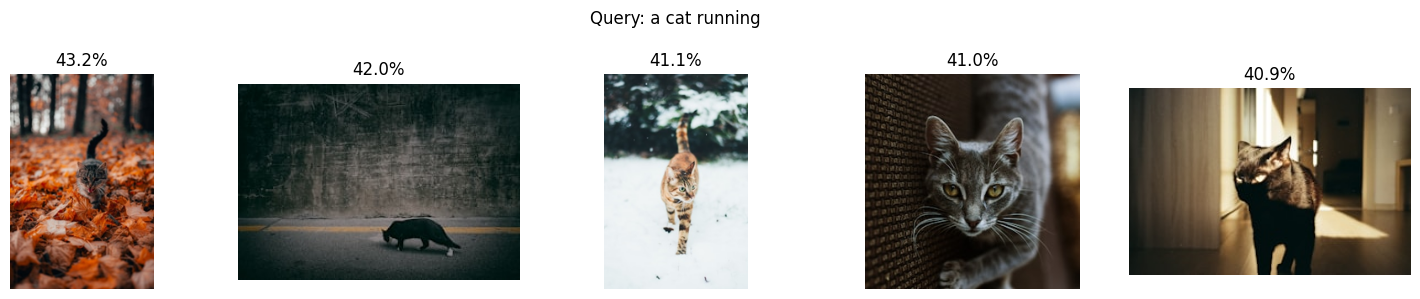

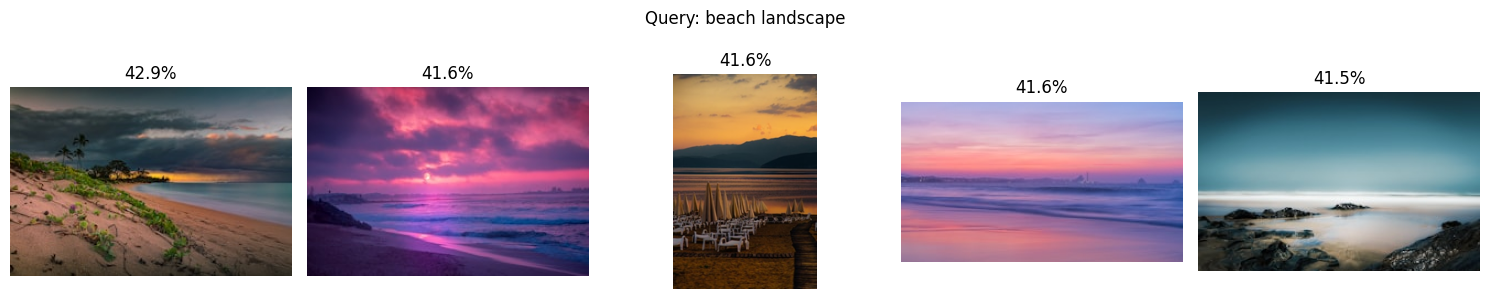

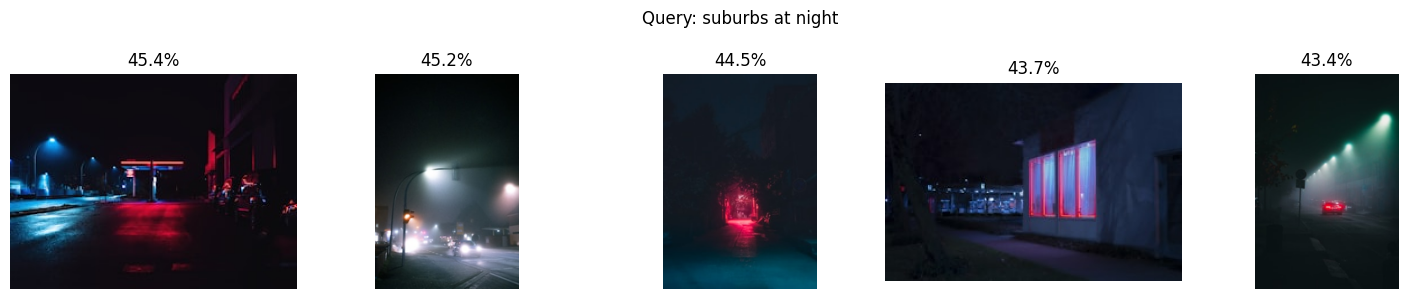

In [11]:
show_text_results("a cat running", k=5)
show_text_results("beach landscape", k=5)
show_text_results("suburbs at night", k=5)

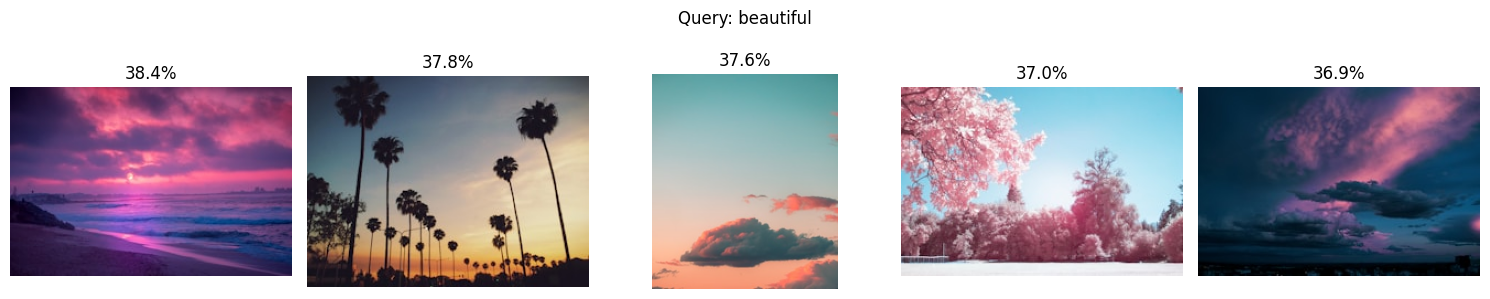

In [8]:
show_text_results("beautiful", k=5)

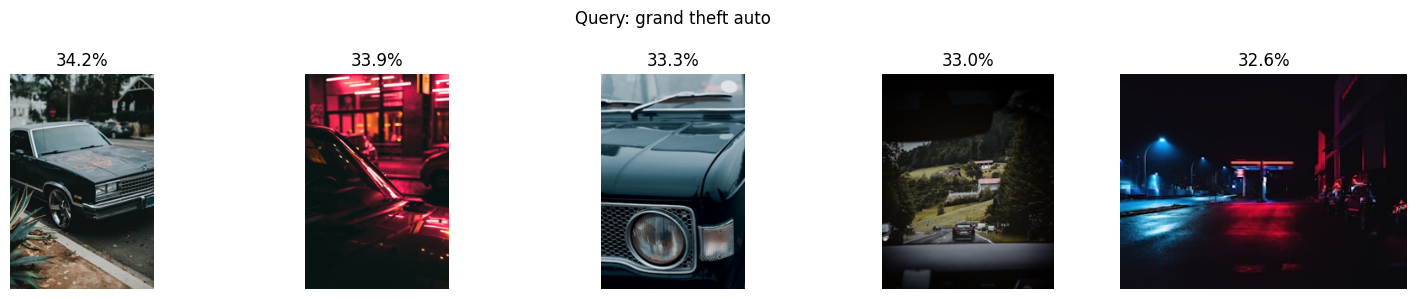

In [9]:
show_text_results("grand theft auto", k=5)

In [10]:
results, scores = search_text("a dog running", k=5)

for r, s in zip(results, scores):
    print(r, f"{s*100:.1f}%")

3rcxLx-NfvQ 45.8%
Z8xcUWGJ9-Y 45.4%
-ZaQMp3-53M 43.6%
lkzjENdWgd8 43.1%
j3BlBeBwxHo 43.0%
